In [1]:
import sys

print(sys.executable)

/home/soorya/Documents/capstone/HAIP/.venv/bin/python


In [2]:
pip install pandas 

Note: you may need to restart the kernel to use updated packages.


In [3]:
# --- Imports ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# --- Plot styling ---
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# --- Make etl/ importable from the notebooks folder ---
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))  # project root

from etl.config import DB_URL

In [4]:
# --- Connect to PostgreSQL and load silver tables ---
engine = create_engine(DB_URL)

silver_tables = ["patients", "mortality", "billing", "icu", "labs"]
data = {
    name: pd.read_sql(f"SELECT * FROM silver.{name}", engine)
    for name in silver_tables
}

# quick confirmation
for name, df in data.items():
    print(f"{name:12s} -> {df.shape[0]:>6} rows, {df.shape[1]:>3} cols")

patients     ->  15757 rows,  57 cols
mortality    ->    359 rows,   7 cols
billing      ->    984 rows,  11 cols
icu          ->   5000 rows,  78 cols
labs         ->     27 rows,  12 cols


In [5]:
# --- Profiling helper ---
def profile(name: str) -> None:
    """Print shape, dtypes, and summary stats for a silver table."""
    df = data[name].drop(columns=["_loaded_at"], errors="ignore")
    print(f"{'='*60}\n{name.upper()} — {df.shape[0]} rows x {df.shape[1]} cols\n{'='*60}")
    print("\nDtypes:")
    print(df.dtypes.value_counts())
    print("\nFirst rows:")
    display(df.head(3))
    print("\nNumeric summary:")
    display(df.describe().T)

In [6]:
profile("patients")

PATIENTS — 15757 rows x 56 cols

Dtypes:
int64      39
float64     9
str         6
object      2
Name: count, dtype: int64

First rows:


,sno,mrd_no,doa,dod,age,gender,rural,type_of_admission,month_year,duration_of_stay,...,congenital,uti,neuro_cardiogenic_syncope,orthostatic,infective_endocarditis,dvt,cardiogenic_shock,shock,pulmonary_embolism,chest_infection
0,1,234735,2017-04-01,2017-04-03,81,Male,Rural,Emergency,Apr-17,3,...,0,0,0,0,0,0,0,0,0,0.0
1,2,234696,2017-04-01,2017-04-05,65,Male,Rural,Emergency,Apr-17,5,...,0,0,0,0,0,0,0,0,0,0.0
2,3,234882,2017-04-01,2017-04-03,53,Male,Urban,Emergency,Apr-17,3,...,0,0,0,0,0,0,0,0,0,0.0



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
sno,15757.0,7879.000000,4548.798431,1.000,3940.00,7879.0,11818.0,15757.00
age,15757.0,61.426160,13.420862,4.000,54.00,62.0,70.0,110.00
duration_of_stay,15757.0,6.415054,5.011421,1.000,3.00,5.0,8.0,98.00
duration_of_icu_stay,15757.0,3.803770,4.015640,0.000,1.00,3.0,5.0,58.00
smoking,15757.0,0.050327,0.218625,0.000,0.00,0.0,0.0,1.00
alcohol,15757.0,0.064797,0.246174,0.000,0.00,0.0,0.0,1.00
dm,15757.0,0.323475,0.467817,0.000,0.00,0.0,1.0,1.00
htn,15757.0,0.485879,0.499816,0.000,0.00,0.0,1.0,1.00
cad,15757.0,0.669607,0.470369,0.000,0.00,1.0,1.0,1.00
prior_cmp,15757.0,0.154471,0.361411,0.000,0.00,0.0,0.0,1.00


In [11]:
# --- Missing value summary across all sources ---
def missing_summary(name: str) -> pd.DataFrame:
    """Return columns with missing values and their percentages."""
    df = data[name].drop(columns=["_loaded_at"], errors="ignore")
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    return pd.DataFrame({
        "missing_count": miss,
        "missing_pct": (miss / len(df) * 100).round(1),
    })

for name in silver_tables:
    print(f"\n--- {name.upper()} ---")
    result = missing_summary(name)
    if result.empty:
        print("No missing values.")
    else:
        display(result)


--- PATIENTS ---


,missing_count,missing_pct
bnp,9081,57.6
doa,5655,35.9
dod,5550,35.2
ef,1599,10.1
glucose,945,6.0
platelets,294,1.9
tlc,290,1.8
hb,256,1.6
creatinine,251,1.6
urea,244,1.5



--- MORTALITY ---


,missing_count,missing_pct
rural_urban,2,0.6



--- BILLING ---
No missing values.

--- ICU ---


,missing_count,missing_pct
glucose,565,11.3
inr,558,11.2
bilirubin_total,557,11.1
hematocrit,554,11.1
creatinine,550,11.0
platelet_count,550,11.0
sodium,531,10.6
hemoglobin,530,10.6
wbc,527,10.5
bicarbonate,511,10.2



--- LABS ---


,missing_count,missing_pct
min_reference,8,29.6
max_reference,8,29.6


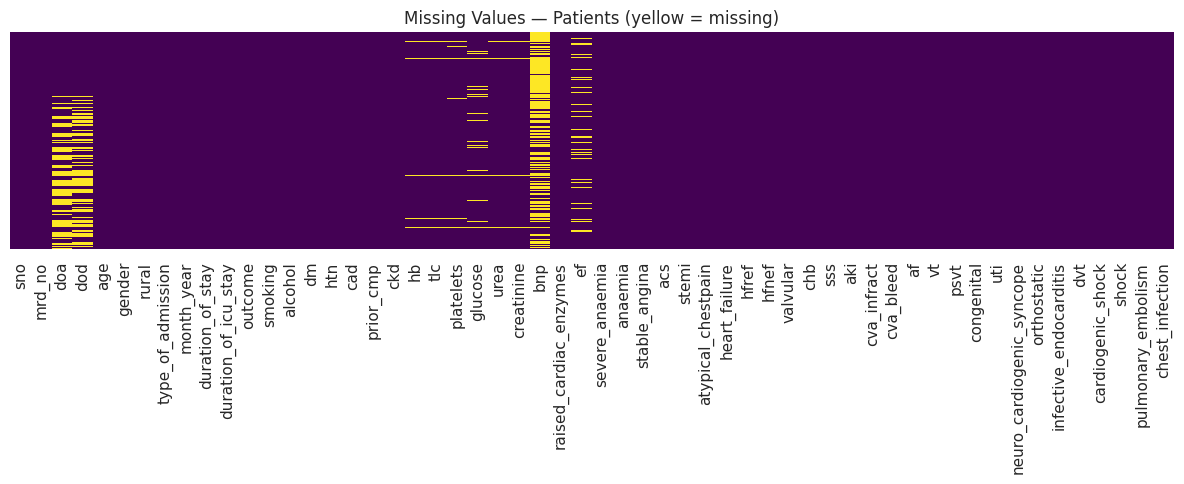

In [12]:
# --- Missing value heatmap (patients) ---
patients = data["patients"].drop(columns=["_loaded_at"], errors="ignore")
plt.figure(figsize=(12, 5))
sns.heatmap(patients.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values — Patients (yellow = missing)")
plt.tight_layout()
plt.show()

In [13]:
# --- Outlier detection via IQR ---
def outlier_summary(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Count outliers per column using the 1.5*IQR rule."""
    rows = []
    for col in cols:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outliers = s[(s < low) | (s > high)]
        rows.append({
            "column": col,
            "outliers": len(outliers),
            "outlier_pct": round(len(outliers) / len(s) * 100, 1),
            "min": round(s.min(), 2),
            "max": round(s.max(), 2),
            "lower_bound": round(low, 2),
            "upper_bound": round(high, 2),
        })
    return pd.DataFrame(rows).sort_values("outlier_pct", ascending=False)

In [14]:
# --- Patients: outliers in clinical measurements ---
patients_clinical = ["age", "duration_of_stay", "duration_of_icu_stay",
                     "hb", "tlc", "platelets", "glucose", "urea",
                     "creatinine", "bnp", "ef"]
display(outlier_summary(patients, patients_clinical))

,column,outliers,outlier_pct,min,max,lower_bound,upper_bound
8,creatinine,1644,10.6,0.06,15.63,-0.20,2.36
7,urea,1371,8.8,0.10,495.00,-24.50,107.50
9,bnp,436,6.5,4.00,5000.00,-1350.00,2570.00
4,tlc,759,4.9,0.10,314.00,-0.35,21.65
6,glucose,716,4.8,1.20,888.00,-29.00,331.00
1,duration_of_stay,736,4.7,1.00,98.00,-4.50,15.50
2,duration_of_icu_stay,683,4.3,0.00,58.00,-5.00,11.00
5,platelets,469,3.0,0.58,1179.00,-4.50,463.50
0,age,362,2.3,4.00,110.00,30.00,94.00
3,hb,125,0.8,3.00,26.50,5.90,18.70


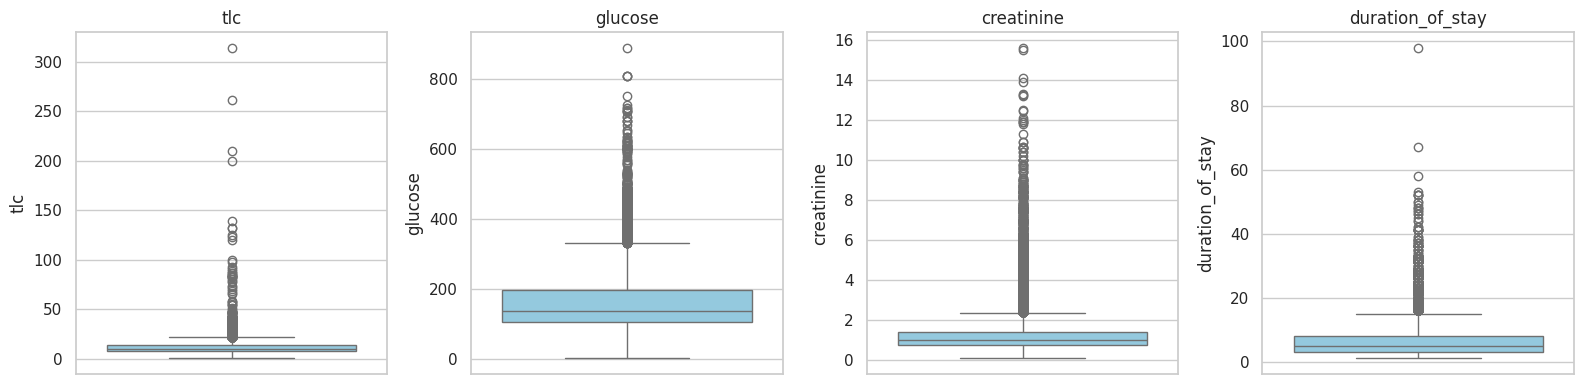

In [15]:
# --- Boxplots for the suspect columns ---
suspect_cols = ["tlc", "glucose", "creatinine", "duration_of_stay"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, suspect_cols):
    sns.boxplot(y=patients[col], ax=ax, color="skyblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [16]:
# --- Patients: outliers in clinical measurements ---
patients_clinical = ["age", "duration_of_stay", "duration_of_icu_stay",
                     "hb", "tlc", "platelets", "glucose", "urea",
                     "creatinine", "bnp", "ef"]
display(outlier_summary(patients, patients_clinical))

,column,outliers,outlier_pct,min,max,lower_bound,upper_bound
8,creatinine,1644,10.6,0.06,15.63,-0.20,2.36
7,urea,1371,8.8,0.10,495.00,-24.50,107.50
9,bnp,436,6.5,4.00,5000.00,-1350.00,2570.00
4,tlc,759,4.9,0.10,314.00,-0.35,21.65
6,glucose,716,4.8,1.20,888.00,-29.00,331.00
1,duration_of_stay,736,4.7,1.00,98.00,-4.50,15.50
2,duration_of_icu_stay,683,4.3,0.00,58.00,-5.00,11.00
5,platelets,469,3.0,0.58,1179.00,-4.50,463.50
0,age,362,2.3,4.00,110.00,30.00,94.00
3,hb,125,0.8,3.00,26.50,5.90,18.70


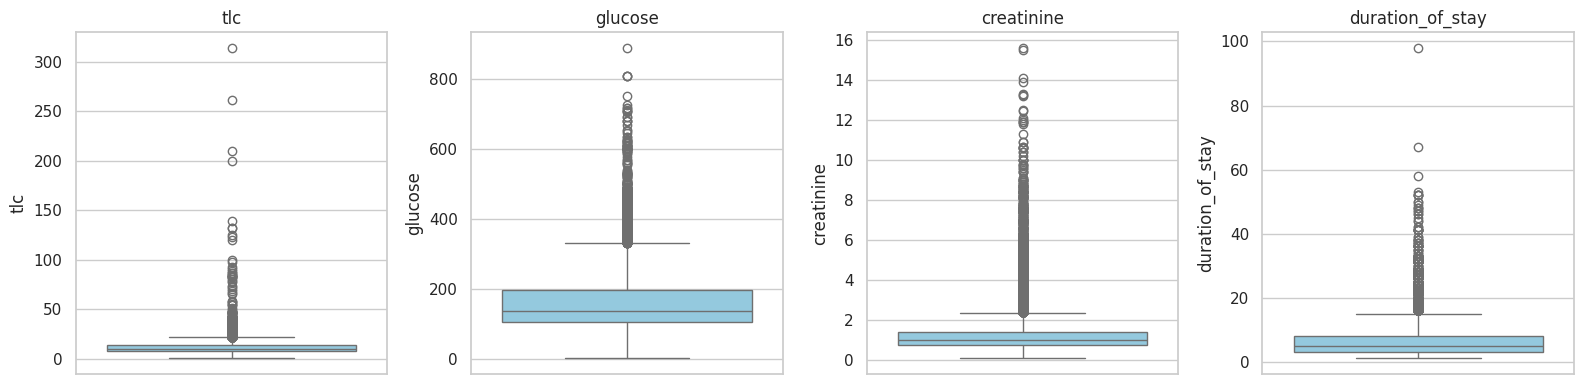

In [17]:
# --- Boxplots for the suspect columns ---
suspect_cols = ["tlc", "glucose", "creatinine", "duration_of_stay"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, suspect_cols):
    sns.boxplot(y=patients[col], ax=ax, color="skyblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [18]:
# --- Flag physiologically implausible values (likely data-entry errors) ---
implausible = {
    "glucose": patients["glucose"] < 20,      # severe hypoglycemia threshold
    "platelets": patients["platelets"] < 10,  # incompatible with survival
    "tlc": patients["tlc"] < 1,               # implausibly low WBC
    "creatinine": patients["creatinine"] < 0.1,
}
for col, mask in implausible.items():
    n = mask.sum()
    print(f"{col}: {n} implausibly low values" + (f" -> {patients.loc[mask, col].tolist()}" if 0 < n <= 10 else ""))

glucose: 2 implausibly low values -> [17.0, 1.2]
platelets: 12 implausibly low values
tlc: 8 implausibly low values -> [0.6, 0.94, 0.4, 0.7, 0.3, 0.9, 0.9, 0.1]
creatinine: 4 implausibly low values -> [0.065, 0.09, 0.08, 0.08]


In [7]:
profile("mortality")

MORTALITY — 359 rows x 6 cols

Dtypes:
str       3
int64     2
object    1
Name: count, dtype: int64

First rows:


,sno,mrd,age,gender,rural_urban,date_of_brought_dead
0,353,235134,64,Male,Urban,2017-04-02
1,301,235138,50,Female,Rural,2017-04-02
2,302,236880,78,Male,Rural,2017-04-04



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
sno,359.0,180.000000,103.778611,1.0,90.5,180.0,269.5,359.0
age,359.0,62.651811,13.133976,5.0,55.0,63.0,72.0,95.0


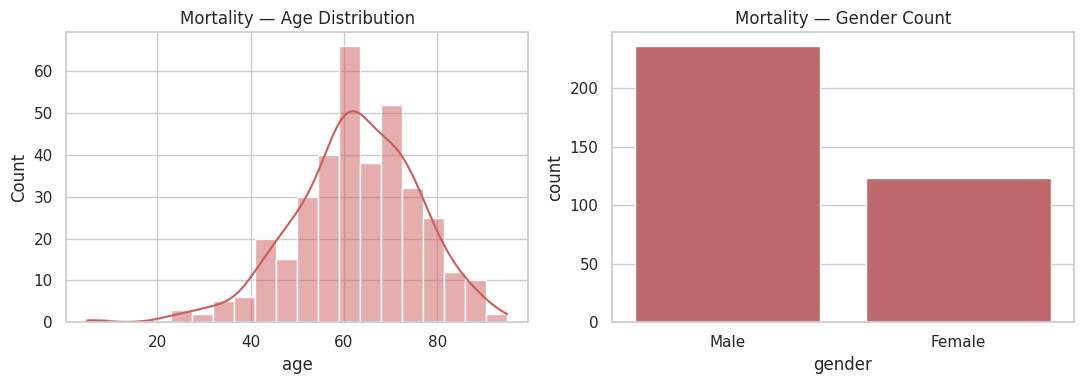

In [24]:
# --- Mortality EDA ---
mortality = data["mortality"].drop(columns=["_loaded_at"], errors="ignore")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(mortality["age"].dropna(), bins=20, kde=True, ax=axes[0], color="indianred")
axes[0].set_title("Mortality — Age Distribution")
sns.countplot(data=mortality, x="gender", ax=axes[1], color="indianred")
axes[1].set_title("Mortality — Gender Count")
plt.tight_layout()
plt.show()

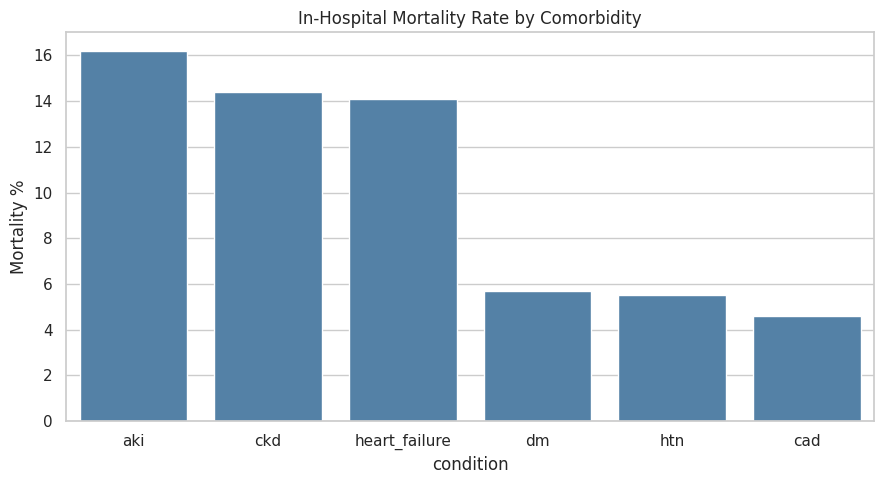

,condition,mortality_pct
5,aki,16.2
3,ckd,14.4
4,heart_failure,14.1
0,dm,5.7
1,htn,5.5
2,cad,4.6


In [23]:
# --- Domain insight 1: mortality rate by comorbidity ---
comorbidities = ["dm", "htn", "cad", "ckd", "heart_failure", "aki"]
mortality_rates = []
for c in comorbidities:
    with_cond = patients[patients[c] == 1]
    rate = (with_cond["outcome"] == "Expiry").mean() * 100
    mortality_rates.append({"condition": c, "mortality_pct": round(rate, 1)})

mort_df = pd.DataFrame(mortality_rates).sort_values("mortality_pct", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=mort_df, x="condition", y="mortality_pct", color="steelblue")
plt.title("In-Hospital Mortality Rate by Comorbidity")
plt.ylabel("Mortality %")
plt.tight_layout()
plt.show()

display(mort_df)

In [8]:
profile("billing")

BILLING — 984 rows x 10 cols

Dtypes:
str        5
int64      3
float64    1
bool       1
Name: count, dtype: int64

First rows:


,patient_id,age,gender,condition,procedure,cost,length_of_stay,readmission,outcome,satisfaction
0,1,45,Female,Heart Disease,Angioplasty,15000.0,5,False,Recovered,4
1,2,60,Male,Diabetes,Insulin Therapy,2000.0,3,True,Stable,3
2,3,32,Female,Fractured Arm,X-Ray and Splint,500.0,1,False,Recovered,5



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
age,984.0,53.754065,14.941135,25.0,45.0,55.0,65.00,78.0
cost,984.0,8367.479675,7761.990976,100.0,1000.0,6000.0,15000.00,25000.0
length_of_stay,984.0,37.663618,19.595805,1.0,21.0,38.0,54.25,76.0
satisfaction,984.0,3.598577,0.883002,2.0,3.0,4.0,4.00,5.0


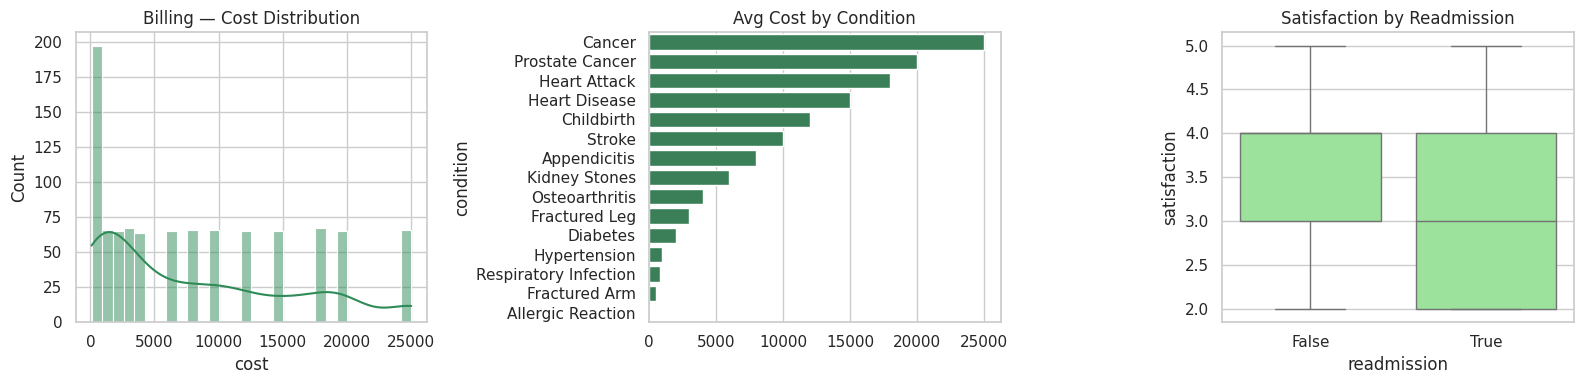

In [25]:
# --- Billing EDA ---
billing = data["billing"].drop(columns=["_loaded_at"], errors="ignore")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# cost distribution
sns.histplot(billing["cost"], bins=30, kde=True, ax=axes[0], color="seagreen")
axes[0].set_title("Billing — Cost Distribution")

# avg cost by condition
cost_by_cond = billing.groupby("condition")["cost"].mean().sort_values(ascending=False)
sns.barplot(x=cost_by_cond.values, y=cost_by_cond.index, ax=axes[1], color="seagreen")
axes[1].set_title("Avg Cost by Condition")

# satisfaction vs readmission
sns.boxplot(data=billing, x="readmission", y="satisfaction", ax=axes[2], color="lightgreen")
axes[2].set_title("Satisfaction by Readmission")

plt.tight_layout()
plt.show()

In [9]:
profile("icu")

ICU — 5000 rows x 77 cols

Dtypes:
float64    53
int64      19
str         5
Name: count, dtype: int64

First rows:


,subject_id,age,gender,weight_kg,height_cm,bmi,ethnicity,insurance,hr_mean,hr_max,...,apache_iv,qsofa,sirs_criteria,gcs_total,icu_los_hours,hospital_admit_source,icu_admit_time_hour,day_of_week,readmission_30day,sepsis_label
0,37464,72,Male,99.5,160.6,38.6,Black,Medicare,83.0,98.7,...,47.9,2.0,1.0,12.0,27.0,OR,15,2,1,1
1,34024,62,Male,101.2,164.5,37.4,Other,Private,97.5,105.8,...,35.0,1.0,1.0,6.0,21.5,Transfer,21,2,0,0
2,65291,74,Male,64.0,167.2,22.9,White,Private,100.6,105.8,...,29.0,1.0,1.0,11.0,46.7,ED,19,6,0,0



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
age,5000.0,64.271600,14.287136,18.0,55.000,65.0,74.000,89.0
weight_kg,5000.0,74.882440,18.609579,45.0,63.500,73.7,84.400,241.9
height_cm,5000.0,170.042780,9.498858,150.0,163.400,170.1,176.625,190.0
bmi,4749.0,25.835965,5.876215,12.5,21.600,25.6,29.600,48.4
hr_mean,5000.0,90.632460,21.764086,40.0,76.975,88.3,100.500,239.5
...,...,...,...,...,...,...,...,...
icu_los_hours,5000.0,48.171620,48.757138,1.0,13.600,33.5,66.400,500.0
icu_admit_time_hour,5000.0,12.885800,6.481200,0.0,7.000,14.0,19.000,23.0
day_of_week,5000.0,3.760800,1.931613,1.0,2.000,4.0,5.000,7.0
readmission_30day,5000.0,0.053800,0.225645,0.0,0.000,0.0,0.000,1.0


In [19]:
# --- ICU: outliers in key clinical measurements ---
icu = data["icu"].drop(columns=["_loaded_at"], errors="ignore")
icu_clinical = ["age", "weight_kg", "bmi", "hr_mean", "sbp_mean", "spo2_mean",
                "temp_celsius_mean", "wbc", "lactate_mmol", "creatinine",
                "glucose", "sofa_score", "apache_iv", "gcs_total", "icu_los_hours"]
display(outlier_summary(icu, icu_clinical))

,column,outliers,outlier_pct,min,max,lower_bound,upper_bound
8,lactate_mmol,647,12.9,0.50,15.00,-0.28,2.08
9,creatinine,490,11.0,1.25,9.54,0.86,3.71
5,spo2_mean,258,5.2,83.60,100.00,91.65,101.65
11,sofa_score,244,4.9,3.00,17.00,4.00,12.00
14,icu_los_hours,244,4.9,1.00,500.00,-65.60,145.60
12,apache_iv,188,3.8,1.30,101.20,1.46,68.76
7,wbc,167,3.7,2.56,49.51,1.27,17.79
3,hr_mean,167,3.3,40.00,239.50,41.69,135.79
10,glucose,91,2.1,50.00,306.00,28.00,220.00
1,weight_kg,51,1.0,45.00,241.90,32.15,115.75


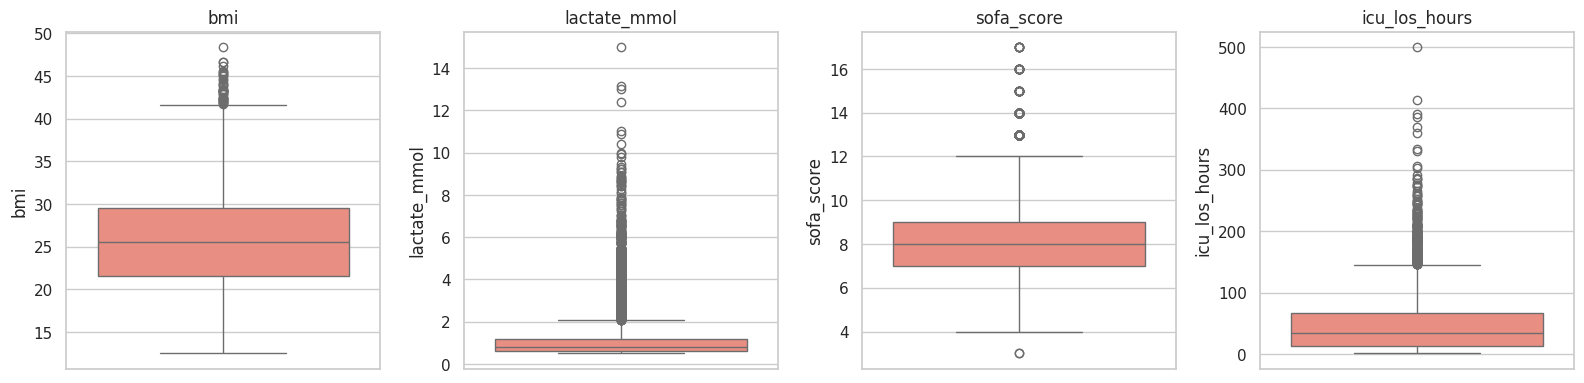

In [20]:
# --- ICU boxplots for vitals/severity ---
icu_suspect = ["bmi", "lactate_mmol", "sofa_score", "icu_los_hours"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, icu_suspect):
    sns.boxplot(y=icu[col], ax=ax, color="salmon")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [21]:
# --- Flag physiologically implausible ICU values ---
icu_implausible = {
    "temp_celsius_mean": (icu["temp_celsius_mean"] < 34) | (icu["temp_celsius_mean"] > 43),
    "hr_mean": icu["hr_mean"] > 220,
    "spo2_mean": icu["spo2_mean"] > 100,
    "weight_kg": icu["weight_kg"] > 250,
}
for col, mask in icu_implausible.items():
    n = mask.sum()
    print(f"{col}: {n} implausible" + (f" -> {sorted(icu.loc[mask, col].tolist())}" if 0 < n <= 12 else ""))

temp_celsius_mean: 13 implausible
hr_mean: 4 implausible -> [224.3, 227.9, 229.2, 239.5]
spo2_mean: 0 implausible
weight_kg: 0 implausible


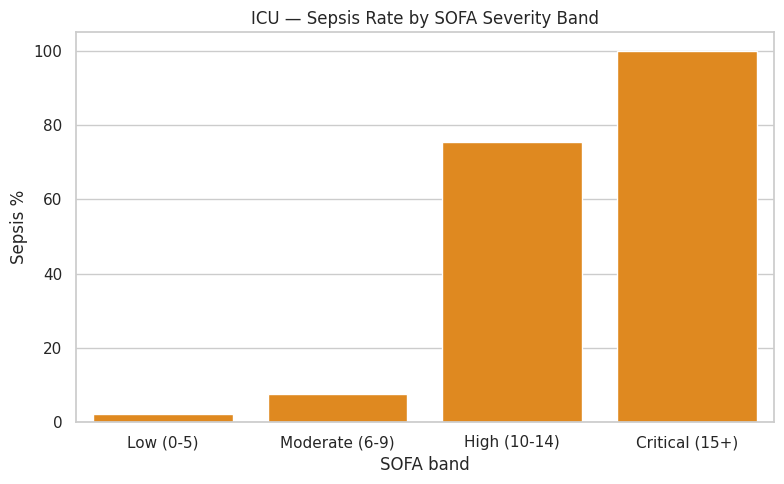

sofa_band
Low (0-5)           2.3
Moderate (6-9)      7.6
High (10-14)       75.3
Critical (15+)    100.0
Name: sepsis_label, dtype: float64

In [27]:
# --- ICU domain insight: sepsis rate & mortality proxy by SOFA band ---
icu = data["icu"].drop(columns=["_loaded_at"], errors="ignore")
icu_valid = icu[icu["sofa_score"].notna()].copy()
icu_valid["sofa_band"] = pd.cut(
    icu_valid["sofa_score"], bins=[0, 6, 10, 15, 25],
    labels=["Low (0-5)", "Moderate (6-9)", "High (10-14)", "Critical (15+)"]
)

sepsis_by_band = icu_valid.groupby("sofa_band", observed=True)["sepsis_label"].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=sepsis_by_band.index, y=sepsis_by_band.values, color="darkorange")
plt.title("ICU — Sepsis Rate by SOFA Severity Band")
plt.ylabel("Sepsis %")
plt.xlabel("SOFA band")
plt.tight_layout()
plt.show()

display(sepsis_by_band.round(1))

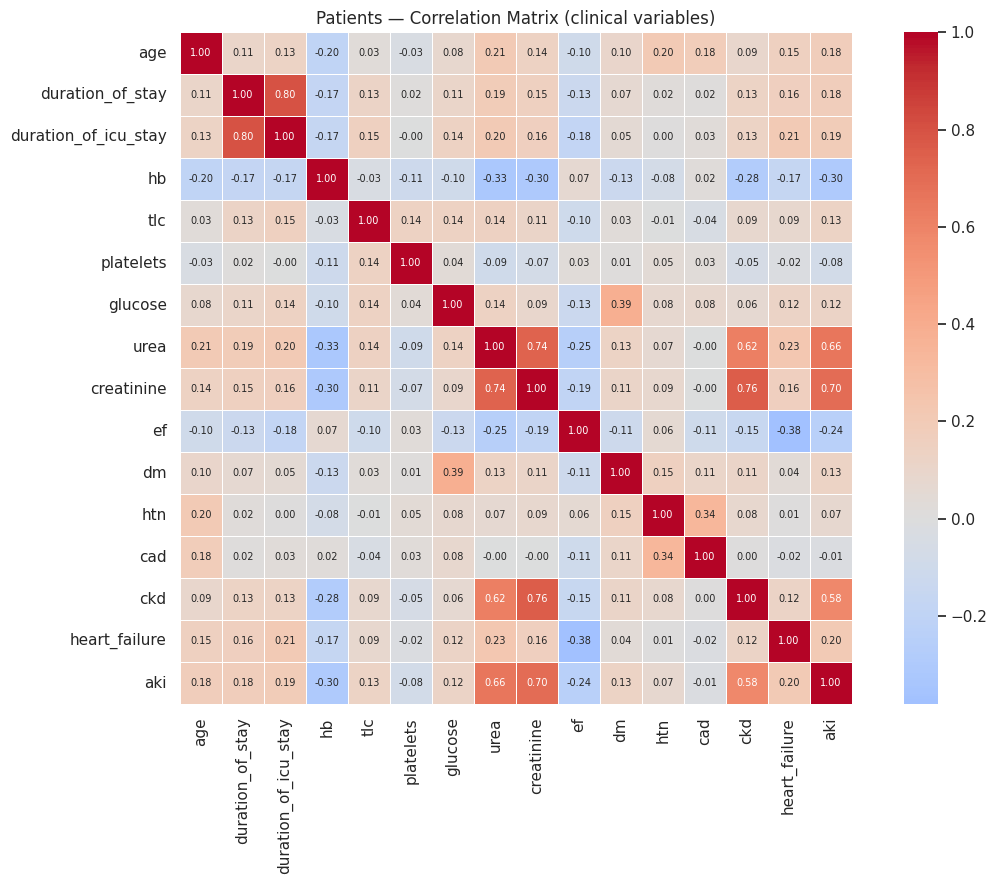

In [22]:
# --- Patients: correlation of key clinical variables ---
corr_cols = ["age", "duration_of_stay", "duration_of_icu_stay", "hb", "tlc",
             "platelets", "glucose", "urea", "creatinine", "ef",
             "dm", "htn", "cad", "ckd", "heart_failure", "aki"]
corr = patients[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, annot_kws={"size": 7})
plt.title("Patients — Correlation Matrix (clinical variables)")
plt.tight_layout()
plt.show()

In [10]:
profile("labs")

LABS — 27 rows x 11 cols

Dtypes:
str        8
float64    2
object     1
Name: count, dtype: int64

First rows:


,date,test_name,result,unit,reference_range,status,comment,min_reference,max_reference,unit_description,recommended_followup
0,2025-08-12,Ferritin,28.9,ug/L,15-150,Normal,Demir depoları alt-orta seviyede,15.0,150.0,Mikrogram/Litre,Demir açısından zengin beslenme
1,2025-08-12,Glikozile Hemoglobin (HbA1c),5.0,%,4.0-6.0,Normal,Kan şekeri uzun dönem ortalaması iyi,4.0,6.0,Yüzde,Mevcut düzeni koruma
2,2025-08-12,Total IgE,1.73,KU/L,0.1-100,Normal,Alerji riski düşük,0.1,100.0,KiloÜnite/Litre,Takip gerekmez



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
min_reference,19.0,19.065789,34.687240,0.10,2.3,5.0,16.50,150.0
max_reference,19.0,53.826842,103.509368,0.38,7.5,15.0,47.65,450.0


In [26]:
# --- Labs (small sample — descriptive only) ---
labs = data["labs"].drop(columns=["_loaded_at"], errors="ignore")
print(f"Labs is a small reference sample (n={len(labs)}).")
print(labs["status"].value_counts())

Labs is a small reference sample (n=27).
status
Normal    26
Yüksek     1
Name: count, dtype: int64
